# Notebook 1 — Load the Data

**What this does:** reads the Cheng brain-tumour `.mat` files and turns them into three files for further use:

| File | Contents |
|---|---|
| `images.npy` | all MRI slices, resized to 224×224 |
| `masks.npy` | the radiologist tumour masks (our ground truth) |
| `manifest.csv` | one row per slice: file id, **patient id**, class label |


Dataset: Cheng et al., figshare `10.6084/m9.figshare.1512427` (CC BY 4.0) — 3064 slices, 233 patients, 3 tumour types.

In [1]:
# Cell 1 — install and import

!pip install h5py scikit-image --quiet

from pathlib import Path
import h5py
import numpy as np
import pandas as pd
from skimage.transform import resize
print("imports ok")

imports ok


## Cell 2 — set dataset path

In [2]:
# Cell 2 — dataset path
DATA_ROOT = "/kaggle/input/datasets/souravpaul100304/brain-tumor-dataset/cheng_dataset"   
OUT_DIR   = "/kaggle/working/data"               

In [3]:
# Cell 3 — find the .mat files
mat_files = sorted(Path(DATA_ROOT).rglob("*.mat"), key=lambda p: int(p.stem) if p.stem.isdigit() else 0)
print(f"Found {len(mat_files)} .mat files")
assert len(mat_files) > 0, (
    f"No .mat files under {DATA_ROOT}. Fix the path in Cell 2."
)
print("first:", mat_files[0].name, "| last:", mat_files[-1].name)

Found 3064 .mat files
first: 1.mat | last: 3064.mat


## Cell 4 — the loader functions

Two helpers. `read_pid` decodes the patient ID (stored as character codes, not text). `load_one` reads one file and returns the image, the mask, the label and the PID.

In [4]:
# Cell 4 — loader functions
LABEL_NAMES = {1: "meningioma", 2: "glioma", 3: "pituitary"}
TARGET_SIZE = (224, 224)

def read_pid(cjdata):
    """PID is stored as ASCII character codes. Decode to a string."""
    raw = np.array(cjdata["PID"]).flatten()
    return "".join(chr(int(c)) for c in raw).strip()

def load_one(path):
    with h5py.File(path, "r") as f:
        cjdata = f["cjdata"]
        image = np.array(cjdata["image"], dtype=np.float64).T
        mask  = np.array(cjdata["tumorMask"], dtype=np.uint8).T
        label = int(np.array(cjdata["label"]).flatten()[0])
        pid   = read_pid(cjdata)
    orig_shape = image.shape

    lo, hi = image.min(), image.max()
    image = np.zeros_like(image) if hi <= lo else (image - lo) / (hi - lo)
    image = (image * 255).astype(np.uint8)

    image = resize(image, TARGET_SIZE, order=1, preserve_range=True).astype(np.uint8)
    mask  = resize(mask,  TARGET_SIZE, order=0, preserve_range=True).astype(np.uint8)
    mask  = (mask > 0).astype(np.uint8)
    return image, mask, label, pid, orig_shape

print("functions defined")

functions defined


## Cell 5 — run the loader

This loops over all files and stacks them. Takes a minute or two.

In [5]:
# Cell 5 — load everything
images, masks, rows, failed = [], [], [], []

for path in mat_files:
    try:
        img, msk, label, pid, orig = load_one(path)
    except Exception as e:
        failed.append((path.name, str(e)))
        continue
    images.append(img)
    masks.append(msk)
    rows.append({
        "file_id": int(path.stem) if path.stem.isdigit() else path.stem,
        "pid": pid,
        "label": label,
        "label_name": LABEL_NAMES[label],
        "orig_size": f"{orig[0]}x{orig[1]}",
        "mask_pixels": int(msk.sum()),
    })

images = np.stack(images)
masks  = np.stack(masks)
manifest = pd.DataFrame(rows)
print(f"loaded {len(manifest)} slices, {len(failed)} failed")

loaded 3064 slices, 0 failed


## Cell 6 — save the outputs

In [6]:
# Cell 6 — save
out = Path(OUT_DIR); out.mkdir(parents=True, exist_ok=True)
np.save(out / "images.npy", images)
np.save(out / "masks.npy", masks)
manifest.to_csv(out / "manifest.csv", index=False)
print("saved to", out.resolve())
print("  images.npy  ", images.shape, images.dtype)
print("  masks.npy   ", masks.shape, masks.dtype)
print("  manifest.csv", manifest.shape)

saved to /kaggle/working/data
  images.npy   (3064, 224, 224) uint8
  masks.npy    (3064, 224, 224) uint8
  manifest.csv (3064, 6)


## Cell 7 — sanity checks

**Read these numbers before moving on.** They must match the dataset. If any line is wrong, stop and fix it — everything downstream depends on this being clean.

| Should say | If it doesn't |
|---|---|
| 3064 slices | some files failed to load |
| 233 patients | PID decoding is broken |
| Patients with >1 class: **0** | patient IDs are wrong — do not continue |
| Empty masks: **0** | tell me how many |

In [7]:
# Cell 7 — sanity checks
print(f"Slices   : {len(manifest)}          (expect 3064)")
print(f"Patients : {manifest.pid.nunique()}           (expect 233)")

print("\nSlices per class:")
print(manifest.label_name.value_counts().to_string())

per_pt = manifest.groupby("pid").size()
print(f"\nSlices per patient: min={per_pt.min()}, max={per_pt.max()}, mean={per_pt.mean():.1f}")

multi = manifest.groupby("pid").label.nunique()
print(f"\nPatients with >1 class label: {(multi > 1).sum()}   (must be 0)")
print(f"Slices with empty mask     : {(manifest.mask_pixels == 0).sum()}   (must be 0)")

if failed:
    print("\nFAILED files:")
    for name, err in failed[:5]:
        print(" ", name, "->", err)

Slices   : 3064          (expect 3064)
Patients : 233           (expect 233)

Slices per class:
label_name
glioma        1426
pituitary      930
meningioma     708

Slices per patient: min=1, max=38, mean=13.2

Patients with >1 class label: 0   (must be 0)
Slices with empty mask     : 0   (must be 0)


## Cell 8 — quick look

A visual gut-check: three slices with their tumour masks outlined. Confirms images and masks line up.

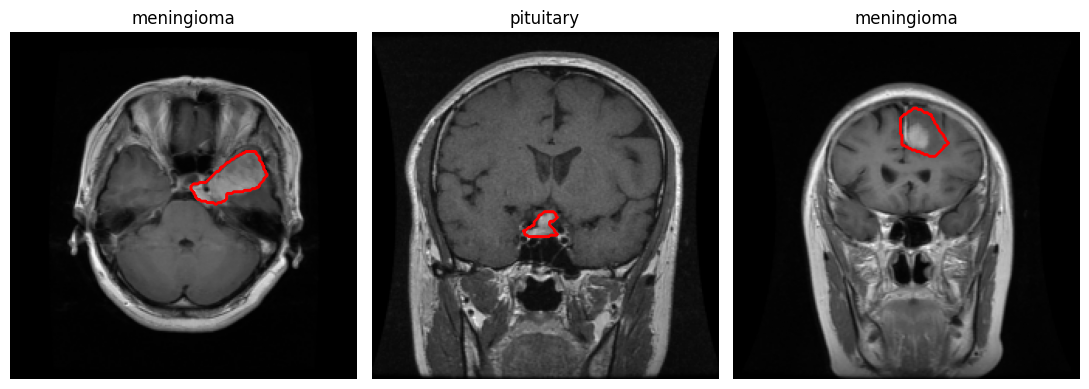

In [8]:
# Cell 8 — visual check (optional)
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, i in zip(axes, [0, len(manifest)//2, len(manifest)-1]):
    ax.imshow(images[i], cmap="gray")
    ax.contour(masks[i], colors="red", linewidths=1)
    ax.set_title(manifest.label_name.iloc[i]); ax.axis("off")
plt.tight_layout(); plt.show()